/tmp/ipykernel_12993/4100470214.py:69: RuntimeWarning: divide by zero encountered in scalar divide
  val = a / β**2 * (b - β**2 - np.log(c + 1/β**2))


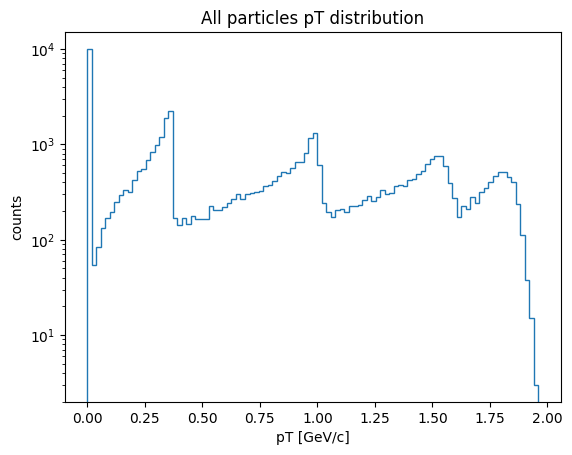

/tmp/ipykernel_12993/4100470214.py:250: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 100)


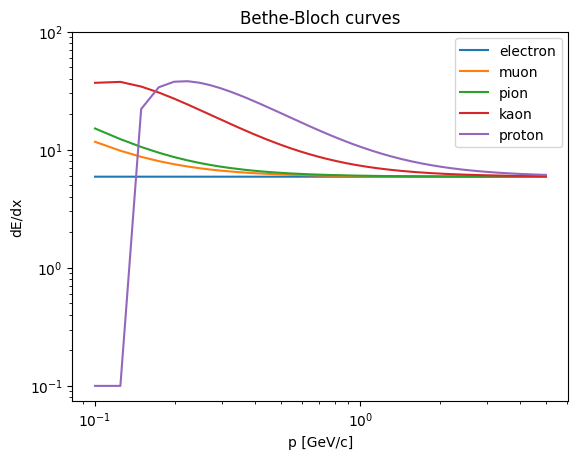

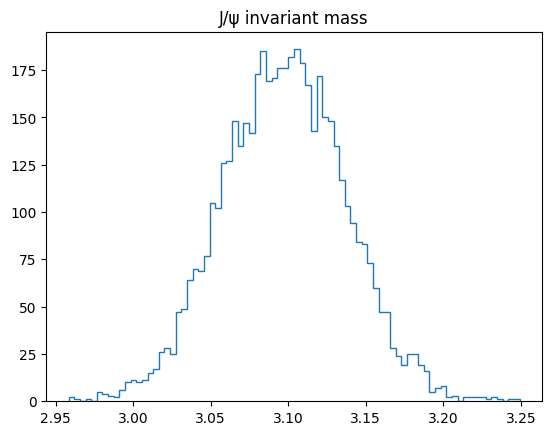

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# 1. TWO-BODY DECAY KINEMATICS (AT REST)
# =============================================================

def p_two_body(M, m1, m2):
    term = (M**2 - (m1 + m2)**2) * (M**2 - (m1 - m2)**2)
    if term < 0:
        return 0
    return np.sqrt(term) / (2 * M)

# =============================================================
# 2. ISOTROPIC DECAY ANGLES
# =============================================================

def angles():
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
    return phi, theta

def momentum_vector(p, phi, theta):
    return np.array([
        p*np.sin(theta)*np.cos(phi),
        p*np.sin(theta)*np.sin(phi),
        p*np.cos(theta)
    ])

# =============================================================
# 3. GENERIC TWO-BODY DECAY GENERATOR
# =============================================================

def generator(M, m1, m2):
    p = p_two_body(M, m1, m2)
    phi, theta = angles()

    p1 = momentum_vector(p, phi, theta)
    p2 = -p1

    return p1, p2

# =============================================================
# 4. PARTICLE MASSES
# =============================================================

masses = {
    "electron": 0.000511,
    "muon":     0.10566,
    "pion":     0.13957,
    "kaon":     0.49368,
    "proton":   0.93827,
    "rho":      0.77526,
    "jpsi":     3.0969,
    "psi2s":    3.6861
}

# =============================================================
# 5. BETHE-BLOCH (ALICE-LIKE PARAMETRIZATION)
# =============================================================

def beta(p, m):
    return p / np.sqrt(p**2 + m**2)

def bethe_bloch(p, m):
    a, b, c = 2.0, 4.0, 0.05
    β = beta(p, m)
    val = a / β**2 * (b - β**2 - np.log(c + 1/β**2))
    return np.maximum(val, 0.1)

TPC_RES = 0.05

def measure_dedx(p, m):
    true = bethe_bloch(p, m)
    return np.random.normal(true, TPC_RES * true)

def nsigma(dedx, p, m_hyp):
    exp = bethe_bloch(p, m_hyp)
    sigma = TPC_RES * exp
    return (dedx - exp) / sigma

# =============================================================
# 6. MOMENTUM SMEARING (ALICE-LIKE)
# =============================================================

def smear(p_vec):
    p = np.linalg.norm(p_vec)
    sigma = np.sqrt(0.01**2 + (0.01*p)**2)
    p_s = np.random.normal(p, sigma*p)
    return p_s * (p_vec/p) if p > 0 else p_vec

# =============================================================
# 7. DECAY CHANNELS
# =============================================================

def rho2pi():
    return generator(masses["rho"], masses["pion"], masses["pion"])

def jpsi2mumu():
    return generator(masses["jpsi"], masses["muon"], masses["muon"])

def psi2s2mumu():
    return generator(masses["psi2s"], masses["muon"], masses["muon"])

def pp():
    return generator(masses["proton"], masses["proton"], masses["proton"])

def gg2ll(m1, m2):
    # effective massless system approximation
    return generator(2.0, m1, m2)

# =============================================================
# 8. EVENT GENERATOR (FULL DETECTOR LEVEL)
# =============================================================

def event_generator(mode, N=10000):

    inv_masses = []
    pt_all = []
    dedx_all = []
    nsig_pi = []
    nsig_p = []
    tracks = []

    for _ in range(N):

        if mode == "rho":
            p1, p2 = rho2pi()
            m_d = masses["pion"]
            M = masses["rho"]

        elif mode == "jpsi":
            p1, p2 = jpsi2mumu()
            m_d = masses["muon"]
            M = masses["jpsi"]

        elif mode == "psi2s":
            p1, p2 = psi2s2mumu()
            m_d = masses["muon"]
            M = masses["psi2s"]

        elif mode == "pp":
            p1, p2 = pp()
            m_d = masses["proton"]
            M = masses["proton"]

        elif mode == "gg":
            p1, p2 = gg2ll(masses["muon"], masses["muon"])
            m_d = masses["muon"]
            M = 0

        else:
            raise ValueError("Unknown mode")

        # =====================================================
        # SMEAR BOTH TRACKS (OPTION A)
        # =====================================================
        p1 = smear(p1)
        p2 = smear(p2)

        # store tracks
        tracks.append(p1)
        tracks.append(p2)

        # =====================================================
        # pT
        # =====================================================
        pt_all.append(np.sqrt(p1[0]**2 + p1[1]**2))
        pt_all.append(np.sqrt(p2[0]**2 + p2[1]**2))

        # =====================================================
        # dE/dx + PID
        # =====================================================
        p1_mag = np.linalg.norm(p1)
        dedx = measure_dedx(p1_mag, m_d)

        dedx_all.append(dedx)
        nsig_pi.append(nsigma(dedx, p1_mag, masses["pion"]))
        nsig_p.append(nsigma(dedx, p1_mag, masses["proton"]))

        # =====================================================
        # INVARIANT MASS
        # =====================================================
        E1 = np.sqrt(np.linalg.norm(p1)**2 + m_d**2)
        E2 = np.sqrt(np.linalg.norm(p2)**2 + m_d**2)

        P4 = np.array([E1 + E2, *(p1 + p2)])
        m_inv = np.sqrt(max(P4[0]**2 - np.linalg.norm(P4[1:])**2, 0))

        inv_masses.append(m_inv)

    return (
        np.array(inv_masses),
        np.array(pt_all),
        np.array(dedx_all),
        np.array(nsig_pi),
        np.array(nsig_p),
        np.array(tracks)
    )

# =============================================================
# 9. ALL DECAYS RUN
# =============================================================

def run_all(N=10000):

    results = {}
    all_pt = []

    for mode in ["rho", "jpsi", "psi2s", "pp", "gg"]:

        inv, pt, dedx, npi, np_, tr = event_generator(mode, N)

        results[mode] = {
            "inv": inv,
            "pt": pt,
            "dedx": dedx,
            "nsig_pi": npi,
            "nsig_p": np_,
            "tracks": tr
        }

        all_pt.append(pt)

    return results, np.concatenate(all_pt)

# =============================================================
# 10. QA PLOTS
# =============================================================

def plot_pt(pt):
    plt.figure()
    plt.hist(pt, bins=100, histtype="step")
    plt.yscale("log")
    plt.xlabel("pT [GeV/c]")
    plt.ylabel("counts")
    plt.title("All particles pT distribution")
    plt.show()

def plot_bb():
    p = np.linspace(0.1, 5, 200)

    plt.figure()

    for name in ["electron", "muon", "pion", "kaon", "proton"]:
        plt.plot(p, bethe_bloch(p, masses[name]), label=name)

    plt.yscale("log")
    plt.ylim(0, 100)
    plt.xscale("log")
    plt.xlabel("p [GeV/c]")
    plt.ylabel("dE/dx")
    plt.title("Bethe-Bloch curves")
    plt.legend()
    plt.show()

# =============================================================
# 11. RUN
# =============================================================

results, all_pt = run_all(N=5000)

plot_pt(all_pt)
plot_bb()

# Example invariant mass plot (J/psi)
plt.hist(results["jpsi"]["inv"], bins=80, histtype="step")
plt.title("J/ψ invariant mass")
plt.show()
